In [6]:
import sys
import os
sys.path.append("../../src/")
#Imports
import single_particle_sector as sps
import kblock_ising_model as kb
import numpy as np
import scipy as sp
import numpy.linalg as la
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, scatter
from collections import Counter
from tqdm import tqdm
import numpy as np
from scipy.integrate import solve_ivp
from joblib import Parallel, delayed

In [7]:
def g(t, tau, g0, gf):
    return max(g0 + (gf - g0) * t / tau, 0)

def rhs(t, v, k, tau, g0, gf):
    return [
        2 * ((g(t, tau, g0, gf) - np.cos(k)) * v[0] + np.sin(k) * v[1]) / 1j,
        2 * (-(g(t, tau, g0, gf) - np.cos(k)) * v[1] + np.sin(k) * v[0]) / 1j
    ]

def evolve_mode_all_times(i, v_0, k, t_span, t_eval, tau, g0, gf):
    v0 = [v_0[0][i] + 0j, v_0[1][i] + 0j]
    ki = k[i]
    res = solve_ivp(rhs, t_span, v0, args=(ki, tau, g0, gf), t_eval=t_eval)
    return res.y  # shape: (2, len(t_eval))



In [68]:
L = 100
g0 = 100
gf = 0
k = kb.k_vals(L)
v_0 = kb.U(k, g0)
taus = np.logspace(-1, 2, 50)
t_eval = np.linspace(0, 2 * taus[-1], 100)  # fixed time grid


In [69]:
# Storage array: (tau_index, time_index, 2, L)
x = np.empty((len(taus), 2, L), dtype=complex)

for j, tau in enumerate(tqdm(taus)):
    t_span = (0, 1.25 * tau)
    t_eval = np.linspace(*t_span, 100)  # time points to integrate over

    results = Parallel(n_jobs=-1)(
        delayed(evolve_mode_all_times)(i, v_0, k, t_span, t_eval, tau, g0, gf)
        for i in range(L)
    )

    results = np.array(results)  # shape: (L, 2, len(t_eval))
    final_uv = results[:, :, -1].T  # shape: (2, L)
    x[j] = final_uv



100%|██████████| 50/50 [00:24<00:00,  2.02it/s]


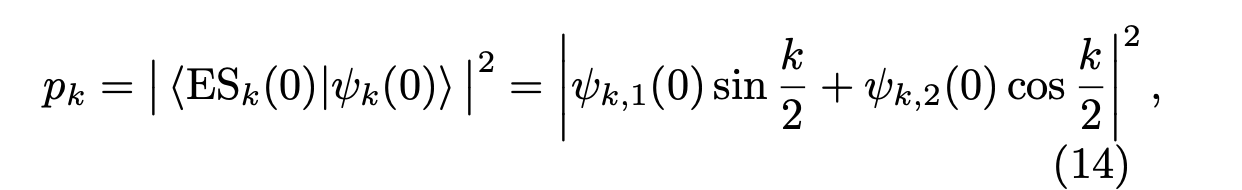

In [89]:
k_index = 54
tau_index = 24
tau_i = taus[tau_index]
k_i = k[k_index]
print(f"k= {k[k_index]}")
print(f"tau= {tau_i}")
v_k = x[tau_index, 0, k_index]
u_k = x[tau_index, 1, k_index]

p_k_numeric = np.abs(u_k*np.sin(k_i/2)+v_k*np.cos(k_i/2))**2

p_k_expected = np.exp(-2*np.pi*tau_i*k_i**2)

print(p_k_numeric)
print(p_k_expected)

k= 0.2827433388230814
tau= 2.9470517025518097
0.7876884475040498
0.2275673528818762


101.0


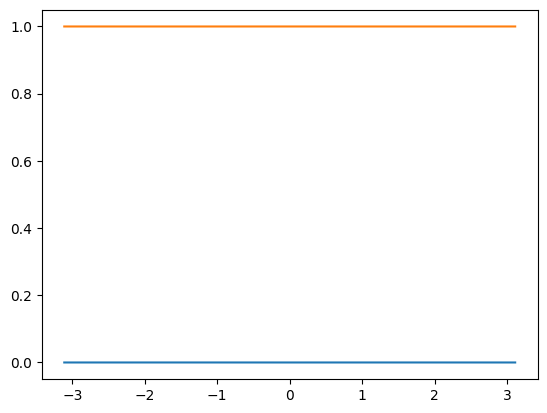

In [384]:
import numpy as np
from mpmath import pcfd, mp

def u_tilde(k,t,tau):
    beta_q = np.sin(k)
    alpha_q = 1+ np.cos(k)
    pf = np.exp(-1j*3*np.pi/4)*beta_q*np.sqrt(tau)*np.exp(-np.pi*beta_q*beta_q*tau/4) 
    nu = 1j*beta_q*beta_q *tau -1 

    arg = np.exp(1j*3*np.pi/4) *2 * (t-alpha_q*tau)/np.sqrt(tau)

    return pf*pcfd(nu,arg)

def v_tilde(k,t,tau):
    beta_q = np.sin(k)
    alpha_q= 1+np.cos(k)
    pf = -np.exp(-np.pi*beta_q*beta_q*tau/4)
    nu = 1j*beta_q*beta_q*tau
    arg = np.exp(1j*3*np.pi/4)*2*(t-alpha_q*tau)/np.sqrt(tau)

    return pf*pcfd(nu,arg)

k = kb.k_vals(100)
x=[]
y=[]
tau = 10
t=-1000
print(-t/tau+1)

for ki in k:
    x+=[abs(v_tilde(ki,t,tau))**2]
    y+=[abs(u_tilde(ki,t,tau))**2]
plt.plot(k,y)
plt.plot(k,x)


In [ ]:
def psi_k10(tau,k):
    pf = np.sqrt(tau)*np.sin(k)*np.exp(-np.pi/4 * tau * np.sin(k)**2)
    nu = -1j*tau*np.sin(k)**2-1
    arg = 2*np.exp(-1j*3*np.pi/4)*np.sqrt(tau)*np.cos(k)
    main = pcfd(nu,arg)
    return complex(pf*main)

def psi_k20(tau,k):
    pf = np.exp(-np.pi/4 * tau *np.sin(k)**2+1j*3*np.pi/4)
    nu = -1j*tau*np.sin(k)**2

    arg = 2*np.exp(-1j*3*np.pi/4)*np.sqrt(tau)*np.cos(k)
    main = pcfd(nu,arg)
    return complex(pf*main)

array([0.03141593, 0.09424778, 0.15707963, 0.21991149, 0.28274334,
       0.34557519, 0.40840704, 0.4712389 , 0.53407075, 0.5969026 ,
       0.65973446, 0.72256631, 0.78539816, 0.84823002, 0.91106187,
       0.97389372, 1.03672558, 1.09955743, 1.16238928, 1.22522113,
       1.28805299, 1.35088484, 1.41371669, 1.47654855, 1.5393804 ,
       1.60221225, 1.66504411, 1.72787596, 1.79070781, 1.85353967,
       1.91637152, 1.97920337, 2.04203522, 2.10486708, 2.16769893,
       2.23053078, 2.29336264, 2.35619449, 2.41902634, 2.4818582 ,
       2.54469005, 2.6075219 , 2.67035376, 2.73318561, 2.79601746,
       2.85884931, 2.92168117, 2.98451302, 3.04734487, 3.11017673])

In [602]:
def G_R(r,t,k,tau):
    #Positive K values
    kp=k[k>0]
    s=0
    for ki in kp:
        ut = u_tilde(ki,t,tau)
        vt = v_tilde(ki,t,tau)
        term_one = 2* np.cos(ki*r)* (np.abs(ut)**2 -np.abs(vt)**2) ##DOUBEL CHECK 
        term_two = -1j*  2* np.sin(ki*r)  *   (ut*np.conj(vt)-np.conj(vt)*ut)
        s+= term_one+term_two
    return -s/len(k)
def D_r(r,t,k,tau):
    return G_R(r+1,t,k,tau)

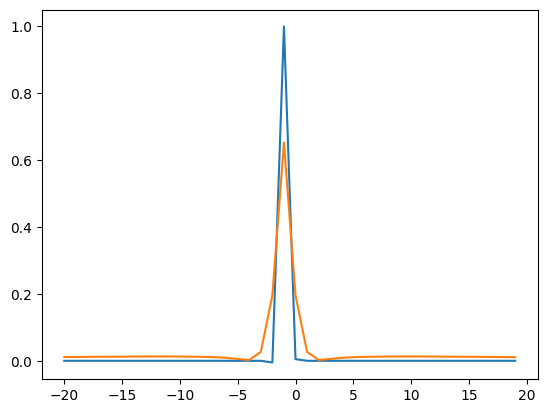

In [603]:
k = kb.k_vals(100)
t = 0
tau = 100
r = -10
x = np.arange(-20,20)
U0=kb.U(k,-100)

z= [kb.D(-xi,U0,k) for xi in x]

y =[D_r(xi,t,k,tau) for xi in x]

plt.plot(x,z)
plt.plot(x,np.abs(y))



In [604]:
def sigma_general(indices,k,tau,t):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)
    #Bs sit on odd sites
    odd_sites = np.array(indices[::2])
    #As site on even sites
    even_sites= np.array(indices[1::2])
    #Get string lengths
    JW_string_lengths = even_sites-odd_sites
    #Sum of string lengths is size of matrix needed
    N = sum(JW_string_lengths)
    #Fill in indices for strings
    R = []
    for i in range(0, len(indices), 2):
        start = indices[i]
        end = indices[i+1]
        R.extend(range(start, end+1))

    A_coords = [x for x in R if x not in odd_sites]
    B_coords = [x for x in R if x not in even_sites]
    C = np.zeros((N,N))
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = abs(D_r(Nd,t,k,tau))
    return np.linalg.det(C)
####PROJECTORS 

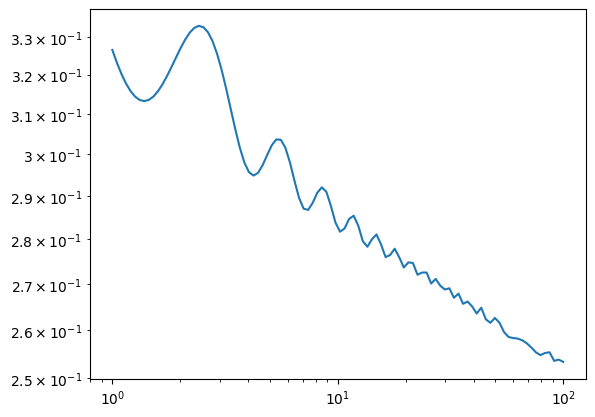

In [605]:
k = kb.k_vals(50)
taus = np.logspace(0,2,100)
teval= 0
plt.loglog(taus,[(1-abs(G_R(1,ti,k,ti)))/2 for ti in taus])
#plt.loglog(taus,1/taus**(1/2))


In [648]:
dat=[]
for tau in taus:  
    s=0
    t = 0
    for ki in k[k>0]:
        ut = u_tilde(ki,t,tau)
        vt = v_tilde(ki,t,tau)
        term_one = np.cos(ki)* (np.abs(ut)**2 -np.abs(vt)**2) ##DOUBEL CHECK 
        term_two = -1j*   np.sin(ki)  *   (ut*np.conj(vt)-np.conj(vt)*ut)
        s+= abs((term_one+term_two+1)/len(k))
    dat.append(s)

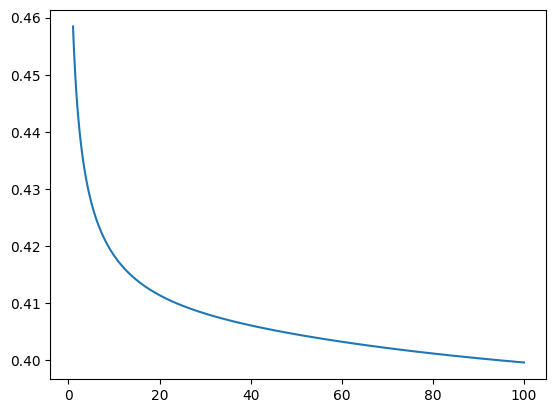

In [649]:
plt.plot(taus,dat)
#plt.plot(taus,(2*taus)**(-1/2))